In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans

In [ ]:

df = pd.read_csv("C:\\Users\\Prem\\Downloads\\climate_dataset_100k.csv")


print(df.head())
print(df.info())

     Country  Year  CO2_Emissions Temperature_Change Sea_Level_Rise  \
0         UK  2006    9909.950609         2.33073612     7.48139504   
1     Canada  2019    1749.885275        0.707943474    0.111917358   
2  Australia  2014    1795.178998        1.650429643     0.37650537   
3         UK  2010    6770.160490        0.909115587    9.659801452   
4  Australia  2007    2225.654204        1.512371753    0.544058997   

  Renewable_Energy Fossil_Fuel_Usage   Population Region  
0      2892.819984       1365.567631  208026129.4  South  
1      846.2645716       5553.569962   1210900745   East  
2       1978.08466       272.5193528   1377290488   East  
3      3560.623928       2296.068204   1127395034   West  
4      495.9730063       5464.709238  998750744.4  North  
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Country         

C:\Users\Prem\AppData\Local\Temp\ipykernel_29948\3119295391.py:2: DtypeWarning: Columns (0: Temperature_Change, 1: Sea_Level_Rise, 2: Renewable_Energy, 3: Fossil_Fuel_Usage, 4: Population) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:\\Users\\Prem\\Downloads\\climate_dataset_100k.csv")


In [20]:
df.describe()

,Year,CO2_Emissions
count,100000.000000,100000.000000
mean,2012.042540,5033.348407
std,7.211719,2876.054951
min,2000.000000,50.108592
25%,2006.000000,2535.451963
50%,2012.000000,5038.530399
75%,2018.000000,7525.353340
max,2024.000000,9999.842725


In [ ]:

df = df.fillna(df.mean(numeric_only=True))


df = df.drop_duplicates()

print(df.isnull().sum())


Country               0
Year                  0
CO2_Emissions         0
Temperature_Change    0
Sea_Level_Rise        0
Renewable_Energy      1
Fossil_Fuel_Usage     0
Population            0
Region                0
dtype: int64


In [22]:
df['CO2_Emissions'] = pd.to_numeric(df['CO2_Emissions'], errors='coerce')
df['Population'] = pd.to_numeric(df['Population'], errors='coerce')

In [23]:
df = df.dropna(subset=['CO2_Emissions', 'Population'])

In [ ]:
import pandas as pd


cols = ['CO2_Emissions', 'Population', 'Temperature_Change',
        'Renewable_Energy', 'Fossil_Fuel_Usage']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


df = df.dropna(subset=cols)


df['Total_Energy'] = df['Renewable_Energy'] + df['Fossil_Fuel_Usage']


df['carbon_footprint'] = df['CO2_Emissions'] / df['Population']


df['renewable_share'] = (df['Renewable_Energy'] / df['Total_Energy']) * 100


df['risk_score'] = (
    0.4 * df['CO2_Emissions'] +
    0.3 * df['Temperature_Change'] -
    0.3 * df['Renewable_Energy']
)


q33 = df['risk_score'].quantile(0.33)
q66 = df['risk_score'].quantile(0.66)


def risk_level(score):
    if score > q66:
        return "High"
    elif score > q33:
        return "Medium"
    else:
        return "Low"

df['risk_level'] = df['risk_score'].apply(risk_level)

print(df.head())

     Country  Year  CO2_Emissions  Temperature_Change Sea_Level_Rise  \
0         UK  2006    9909.950609            2.330736     7.48139504   
1     Canada  2019    1749.885275            0.707943    0.111917358   
2  Australia  2014    1795.178998            1.650430     0.37650537   
3         UK  2010    6770.160490            0.909116    9.659801452   
4  Australia  2007    2225.654204            1.512372    0.544058997   

   Renewable_Energy  Fossil_Fuel_Usage    Population Region  Total_Energy  \
0       2892.819984        1365.567631  2.080261e+08  South   4258.387615   
1        846.264572        5553.569962  1.210901e+09   East   6399.834534   
2       1978.084660         272.519353  1.377290e+09   East   2250.604013   
3       3560.623928        2296.068204  1.127395e+09   West   5856.692132   
4        495.973006        5464.709238  9.987507e+08  North   5960.682244   

   carbon_footprint  renewable_share   risk_score risk_level  
0          0.000048        67.932284  309

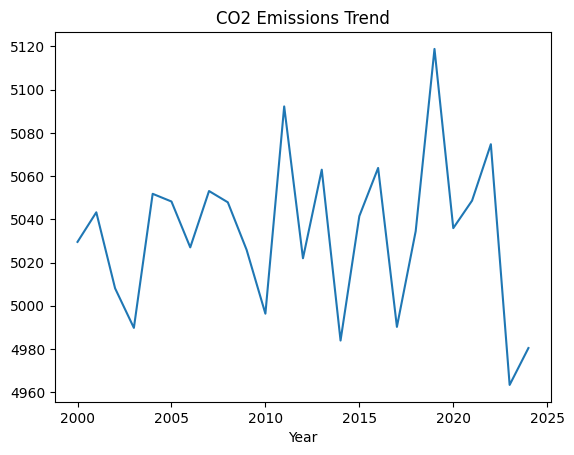

In [ ]:

plt.figure()
df.groupby('Year')['CO2_Emissions'].mean().plot()
plt.title("CO2 Emissions Trend")
plt.show()

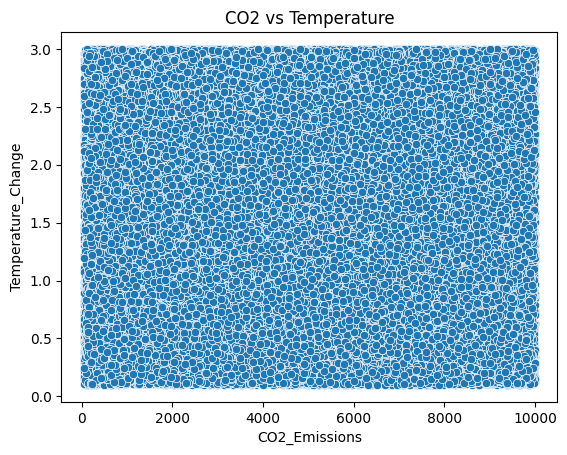

In [ ]:

plt.figure()
sns.scatterplot(x='CO2_Emissions', y='Temperature_Change', data=df)
plt.title("CO2 vs Temperature")
plt.show()

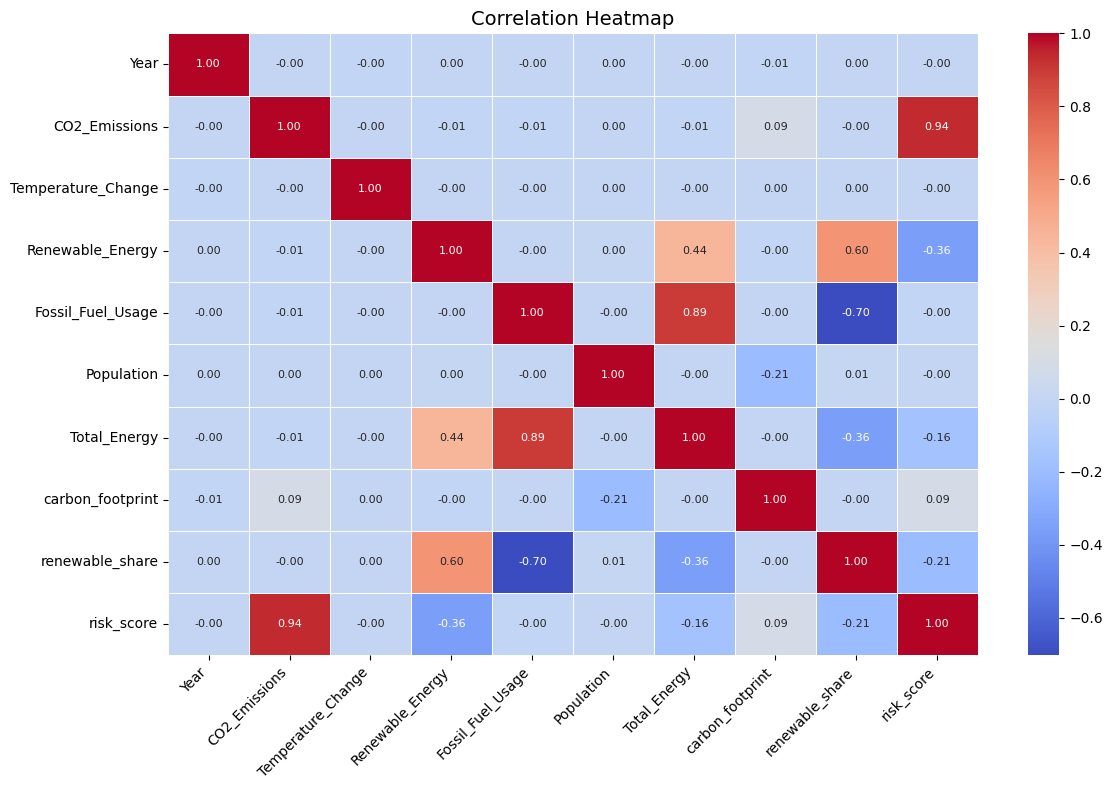

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(12, 8)) 

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",             
    cmap='coolwarm',
    linewidths=0.5,        
    annot_kws={"size": 8}  
)

plt.xticks(rotation=45, ha='right')  
plt.yticks(rotation=0)

plt.title("Correlation Heatmap", fontsize=14)
plt.tight_layout() 

plt.show()

In [ ]:

le = LabelEncoder()
df['risk_level_encoded'] = le.fit_transform(df['risk_level'])


X = df[['CO2_Emissions', 'Temperature_Change', 'Renewable_Energy', 'Population']]
y = df['risk_level_encoded']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9976997699769977

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6859
           1       1.00      1.00      1.00      6528
           2       1.00      1.00      1.00      6611

    accuracy                           1.00     19998
   macro avg       1.00      1.00      1.00     19998
weighted avg       1.00      1.00      1.00     19998



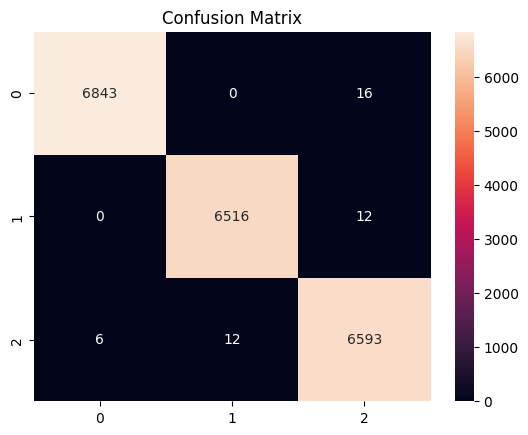

In [ ]:

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

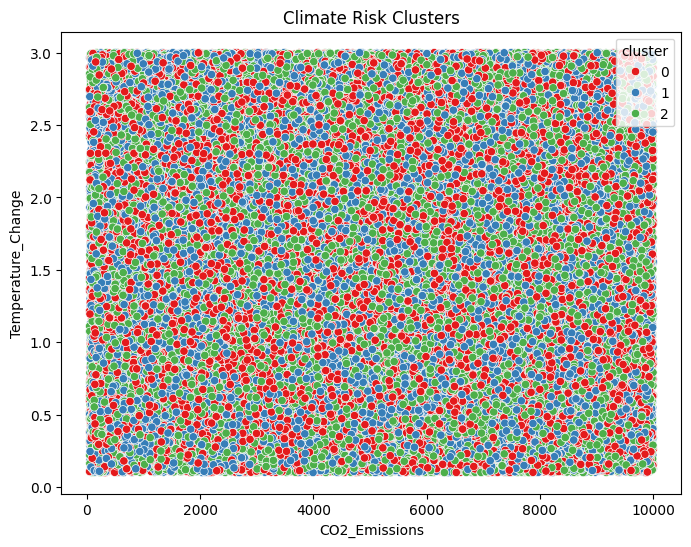

In [ ]:

kmeans = KMeans(n_clusters=3, random_state=42)

df['cluster'] = kmeans.fit_predict(X)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['CO2_Emissions'],
    y=df['Temperature_Change'],
    hue=df['cluster'],
    palette='Set1'   # 👈 change palette here
)

plt.title("Climate Risk Clusters")
plt.show()

In [ ]:

df.to_csv("cleaned_climate_data.csv", index=False)

metrics = df[['Country', 'risk_score', 'risk_level']]
metrics.to_csv("climate_metrics.csv", index=False)

print(" cleaned_climate_data.csv saved successfully")
print(" climate_metrics.csv saved successfully")

✅ cleaned_climate_data.csv saved successfully
✅ climate_metrics.csv saved successfully


In [34]:
print(df.isnull().sum())

Country               0
Year                  0
CO2_Emissions         0
Temperature_Change    0
Sea_Level_Rise        0
Renewable_Energy      0
Fossil_Fuel_Usage     0
Population            0
Region                0
Total_Energy          0
carbon_footprint      0
renewable_share       0
risk_score            0
risk_level            0
risk_level_encoded    0
cluster               0
dtype: int64
